In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
def plotData(X,y):
    plt.figure
    plt.plot(X[np.where(y==1),0],X[np.where(y==1),1],'k+',linewidth = 2,markersize=7)
    plt.plot(X[np.where(y==0),0],X[np.where(y==0),1],'ko',markerfacecolor = 'y',markersize=7)
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend('Admitted', 'Not admitted')
    plt.show()

In [3]:
def sigmoid(z):
    g = np.zeros(z.shape)
    g = 1/(1+np.exp(-z))
    return g

In [4]:
def costFunction(theta,X,y):
    m = len(y)
    J = 0
    h = sigmoid(X@theta)
    #print(theta)
    #plt.figure()
    #plt.scatter(range(0,100),h)
    J = 1/m*(-y.T@np.log(h)-(1-y).T@np.log(1-h))
    return J

In [5]:
def gradient(theta,X,y):
    m = len(y)
    grad = np.zeros(theta.shape)
    h = sigmoid(X@theta)
    grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))
    grad[1:] = 1/m*(X[:,1:].T@(h-y))
    return grad

In [6]:
def plotDecisionBoundary(X,y,theta):
    m,n = X.shape
    plot_x = np.array([np.min(X[:,1])-2, np.max(X[:,1])+2])
    plot_y = -1/theta[2]*(theta[1]*plot_x+theta[0])
    plt.figure
    plt.plot(X[np.where(y==1),1],X[np.where(y==1),2],'k+',linewidth = 2,markersize=7)
    plt.plot(X[np.where(y==0),1],X[np.where(y==0),2],'ko',markerfacecolor = 'y',markersize=7)
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend('Admitted', 'Not admitted')
    plt.plot(plot_x,plot_y,'b-',linewidth=2) 

   exam1_score  exam2_score  admission_status
0    34.623660    78.024693                 0
1    30.286711    43.894998                 0
2    35.847409    72.902198                 0
3    60.182599    86.308552                 1
4    79.032736    75.344376                 1


C:\Users\thein\AppData\Local\Temp\ipykernel_19820\2095019850.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Admitted', 'Not admitted')


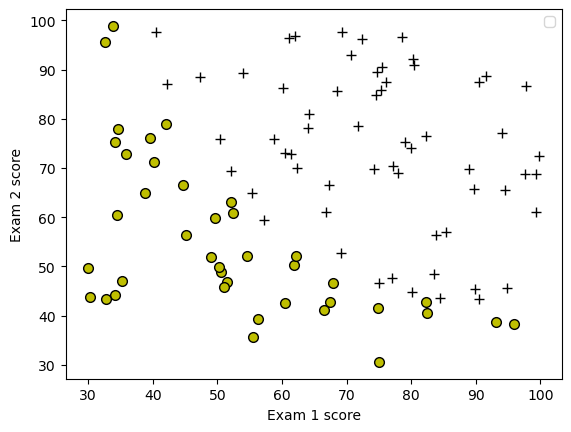

In [14]:
df = pd.read_csv('ex2data1.csv')
df.head()
print(df.head())
X= np.array(df[["exam1_score","exam2_score"]].values)
y = np.array(df["admission_status"].values,ndmin=2).reshape(-1).T
plotData(X,y)

In [15]:
m,n = X.shape
X2 = np.concatenate((np.ones((m,1)),X),axis=1)
theta_ini = np.zeros((n+1))

cost = costFunction(theta_ini, X2, y)
cost

0.6931471805599452

In [16]:
result = minimize(costFunction, theta_ini,(X2,y), method='BFGS',jac=gradient)

# Extract the optimal solution
optimal_theta = result.x

print("Optimal solution:", optimal_theta)
print("Minimum value:", result.fun)

Optimal solution: [-25.16133284   0.2062317    0.2014716 ]
Minimum value: 0.2034977015894438


C:\Users\thein\AppData\Local\Temp\ipykernel_19820\1148710159.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))
C:\Users\thein\AppData\Local\Temp\ipykernel_19820\2859117373.py:8: RuntimeWarning: divide by zero encountered in log
  J = 1/m*(-y.T@np.log(h)-(1-y).T@np.log(1-h))
C:\Users\thein\AppData\Local\Temp\ipykernel_19820\2859117373.py:8: RuntimeWarning: invalid value encountered in matmul
  J = 1/m*(-y.T@np.log(h)-(1-y).T@np.log(1-h))


In [17]:
print('Model represention: {}+{}*x_1+{}*x_2'.format(optimal_theta[0],
                                                    optimal_theta[1],optimal_theta[2])) 

Model represention: -25.161332838910397+0.20623169711535447*x_1+0.20147160270028477*x_2


C:\Users\thein\AppData\Local\Temp\ipykernel_19820\3408205249.py:10: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Admitted', 'Not admitted')


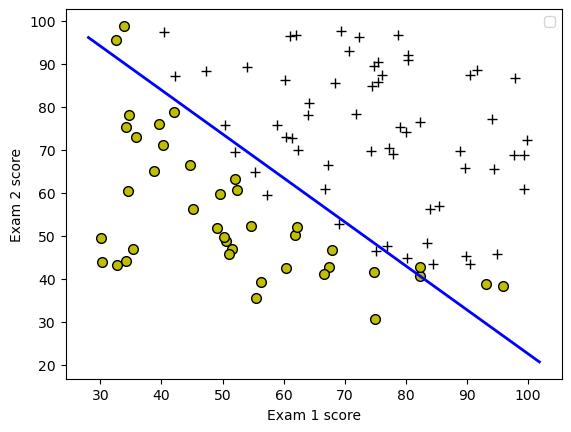

In [18]:
plotDecisionBoundary(X2, y,optimal_theta)

In [19]:
def confusion_matrix(y_true, y_pred):
    # Initialize variables for true positive, true negative, false positive, and false negative
    tp = np.sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    tn = np.sum((np.array(y_pred) == 0) & (np.array(y_true) == 0))
    fp = np.sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = np.sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))

    # Print confusion matrix
    print("Confusion Matrix:")
    print(f"\t\t\t\t\t| Actual False \t| Actual True")
    print(f"Prediction False\t|     {tn}        |      {fn}")
    print(f"Prediction True\t\t|     {fp}         |      {tp}")
    return (tp,tn,fp,fn)

In [20]:
def f1Score(perVars):
    (tp,tn,fp,fn) = perVars
    # Compute precision, recall, and F1 score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print F1 score
    print(f"\nF1 Score: {f1:.2f}")
    return (f1,precision,recall)
    # Compute precision, recall, and F1 score

In [22]:
prediction = sigmoid(X2@optimal_theta)
prediction[np.where(prediction>0.5)] = 1
prediction[np.where(prediction<0.5)] = 0
pervars = confusion_matrix(y, prediction)
F1,Precision,Recall = f1Score(pervars)

Confusion Matrix:
					| Actual False 	| Actual True
Prediction False	|     34        |      5
Prediction True		|     6         |      55

F1 Score: 0.91
